In [1]:
%pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def LBP(image, radius, num_points):
    lbp_image = np.zeros_like(image)
    height, width = image.shape

    for i in range(0, height):
        for j in range(0, width):
            lbp_value = 0
            for k in range(0, num_points):
                theta = 2 * np.pi * k / num_points
                x = int(j + radius * np.cos(theta))
                y = int(i - radius * np.sin(theta))

                if x < 0 or y < 0 or x >= width or y >= height:
                    continue

                if image[y, x] >= image[i, j]:
                    lbp_value += 1 << k

            lbp_image[i, j] = lbp_value

    return lbp_image

In [4]:
image = cv2.imread("blobs.jpeg", cv2.IMREAD_GRAYSCALE)
lbp_radius = 1
num_points = 8
lbp_result = LBP(image, lbp_radius, num_points)

In [6]:
histogram, _ = np.histogram(
    lbp_result, bins=np.arange(0, 2 ** (num_points) + 1), range=(0, 2 ** (num_points))
)

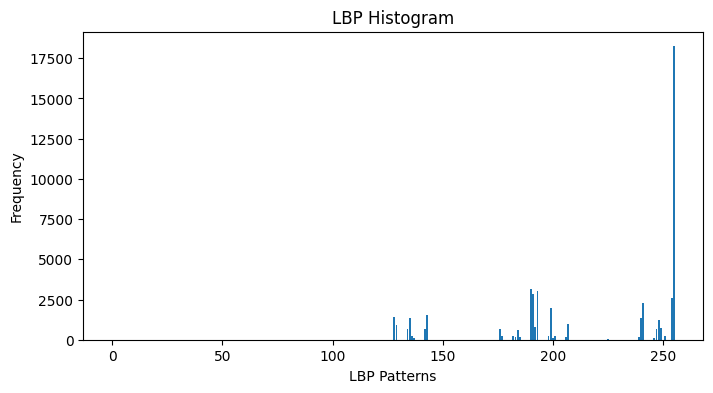

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(histogram)), histogram)
plt.xlabel("LBP Patterns")
plt.ylabel("Frequency")
plt.title("LBP Histogram")
plt.show()

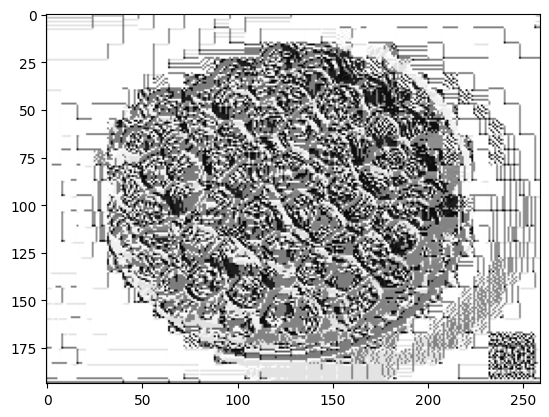

In [5]:
plt.imshow(lbp_result, "gray")